<a href="https://colab.research.google.com/github/Kokunov777/-313-/blob/main/%D0%9B%D0%A01_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F_%D0%92%D0%B0%D1%80%D0%B8%D0%B0%D0%BD%D1%825.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1
## «Линейная регрессия и факторный анализ»
### Вариант 5 — Прогноз продаж продуктов в магазине (Sales Forecasting Dataset)

**Язык программирования:** Python 3
**Среда выполнения:** Google Colab (ноутбук полностью самодостаточен — запускается на «чистом» компьютере без предварительной настройки)

---

## 1. Введение

**Цель работы:** изучение основ линейной регрессии, построение простейших моделей регрессии,
обучение модели на реальных данных и оценка её качества.

**Задачи работы:**

1. Загрузить датасет прогнозирования продаж и провести его первичный анализ.
2. Визуализировать распределения признаков и целевой переменной.
3. Выполнить предобработку: обработку пропусков, кодирование категориальных переменных, масштабирование.
4. Построить корреляционную матрицу, рассчитать коэффициенты VIF и сделать вывод о мультиколлинеарности.
5. Построить три регрессионные модели (линейная, LASSO, гребневая), разделив выборку 80/20,
   с использованием кросс-валидации и подбором гиперпараметра регуляризации.
6. Оценить качество моделей метриками **RMSE**, **R²** и **MAPE**.
7. Устранить мультиколлинеарность и снизить размерность методом главных компонент (PCA)
   после предварительной стандартизации данных.
8. Повторно обучить те же три модели на главных компонентах и сравнить метрики качества.

**Объект исследования:** ежедневные продажи продуктов в розничном магазине.
**Предмет исследования:** зависимость объёма продаж (целевая переменная `sales`) от ценовых,
маркетинговых, календарных и внешних факторов.

---
## 2. Подготовка среды

Ячейка ниже устанавливает недостающие библиотеки. В Google Colab все они уже присутствуют,
поэтому установка занимает несколько секунд и нужна только для запуска на «чистом» компьютере
(локальный Jupyter, новый virtualenv и т. п.).

In [65]:
# --- Установка зависимостей (нужна только на "чистой" машине; в Colab всё уже есть) ---
import importlib.util, subprocess, sys

REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
}

missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Устанавливаются пакеты:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Все необходимые пакеты уже установлены.")

Все необходимые пакеты уже установлены.


In [66]:
# --- Импорт библиотек и глобальные настройки ---
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

RANDOM_STATE = 42          # фиксируем зерно ГСЧ -> результаты воспроизводимы
TEST_SIZE = 0.2            # разделение выборки 80/20
N_SPLITS = 5               # число фолдов кросс-валидации

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("Версии библиотек:")
import sklearn
print(f"  numpy        {np.__version__}")
print(f"  pandas       {pd.__version__}")
print(f"  scikit-learn {sklearn.__version__}")

Версии библиотек:
  numpy        2.1.3
  pandas       2.2.3
  scikit-learn 1.6.1


---
## 3. Описание датасета

### 3.1. Источник данных

Работа выполняется на датасете типа **Sales Forecasting Dataset** (прогноз продаж продуктов в магазине).
Ноутбук поддерживает два режима загрузки данных:

* **Режим A — собственный CSV-файл.** Достаточно указать путь в переменной `CSV_PATH`
  (например, файл `train.csv` из датасета Kaggle
  [Sales Forecasting](https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting) или
  [Store Sales — Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)),
  либо загрузить файл кнопкой «Файлы» слева в Colab. Столбец-цель задаётся в `TARGET_COLUMN`.
* **Режим B — встроенный генератор (по умолчанию).** Если файл не указан или не найден, используется
  встроенный генератор реалистичных данных о продажах: 1800 наблюдений (ежедневные продажи
  за ~5 лет), 15 признаков со **специально заложенной мультиколлинеарностью**
  (`price` ↔ `competitor_price`, `store_traffic` ↔ `customers`, `ad_spend` ↔ `ad_spend_lag7`)
  и пропущенными значениями. Такой режим гарантирует, что ноутбук полностью отработает
  на любом компьютере без интернета, ключей Kaggle API и ручной загрузки файлов.

### 3.2. Состав признаков (режим B)

| Признак | Тип | Описание |
|---|---|---|
| `date` | дата | дата наблюдения (используется только для календарных признаков) |
| `day_of_week` | int | день недели (0 — понедельник … 6 — воскресенье) |
| `month` | int | номер месяца |
| `is_weekend` | bin | признак выходного дня |
| `is_holiday` | bin | признак праздничного дня |
| `store_size_m2` | float | торговая площадь магазина, м² |
| `price` | float | средняя цена товара, у.е. |
| `competitor_price` | float | средняя цена аналогичного товара у конкурента |
| `discount_pct` | float | средняя скидка, % |
| `promo` | bin | наличие промоакции |
| `ad_spend` | float | расходы на рекламу за день, у.е. |
| `ad_spend_lag7` | float | расходы на рекламу неделей ранее |
| `store_traffic` | float | посещаемость магазина (число вошедших) |
| `customers` | float | число покупателей (совершивших покупку) |
| `temperature` | float | среднесуточная температура, °C |
| `competitors_nearby` | int | число конкурентов в радиусе 1 км |
| **`sales`** | **float** | **целевая переменная — выручка за день, у.е.** |

Целевая переменная **количественная**, поэтому решается задача **регрессии**
(логистическая регрессия не применяется).

In [67]:
# ======================= ЗАГРУЗКА ДАННЫХ =======================
# Режим A: укажите путь к своему CSV-файлу и имя целевого столбца.
CSV_PATH = None            # например: "/content/train.csv"
TARGET_COLUMN = "sales"    # например: "Sales"


def generate_sales_dataset(n: int = 1800, seed: int = RANDOM_STATE) -> pd.DataFrame:
    # Генерирует реалистичный набор данных о ежедневных продажах магазина.
    # В данные намеренно заложены:
    #   * линейная зависимость продаж от набора факторов (есть что моделировать);
    #   * мультиколлинеарность (цена ~ цена конкурента, трафик ~ покупатели, реклама ~ её лаг);
    #   * шум, сезонность и пропуски (как в реальных выгрузках).
    rng = np.random.default_rng(seed)
    date = pd.date_range("2020-01-01", periods=n, freq="D")
    dow = date.dayofweek.values
    month = date.month.values

    store_size = rng.choice([120, 250, 400, 650], size=n)
    price = np.round(rng.normal(100, 15, n).clip(55, 160), 2)
    # цена конкурента почти повторяет нашу цену -> источник мультиколлинеарности
    competitor_price = np.round(price * rng.normal(1.0, 0.03, n) + rng.normal(0, 2, n), 2)
    discount = np.round(
        rng.choice([0, 5, 10, 15, 20, 25], n, p=[.35, .20, .17, .13, .10, .05])
        + rng.normal(0, 0.6, n), 2).clip(0, 30)
    promo = (discount > 8).astype(int)
    ad_spend = np.round(rng.gamma(4, 300, n) + promo * 900, 2)
    # реклама неделей ранее сильно коррелирует с текущей рекламой
    ad_spend_lag7 = np.round(0.85 * np.roll(ad_spend, 7) + rng.normal(0, 120, n), 2).clip(50, None)
    temperature = np.round(12 + 11 * np.sin(2 * np.pi * (date.dayofyear.values - 100) / 365)
                           + rng.normal(0, 3, n), 1)
    is_holiday = (((date.dayofyear.values % 61) == 0) |
                  ((month == 12) & (date.day.values > 20))).astype(int)
    traffic = (300 + 0.45 * store_size + 60 * (dow >= 5) + 0.02 * ad_spend
               + 40 * is_holiday + 4 * discount + rng.normal(0, 45, n)).clip(50, None)
    # покупатели - это доля трафика -> практически линейная зависимость
    customers = (0.38 * traffic + 6 * promo + rng.normal(0, 12, n)).clip(10, None)
    competitors_nearby = rng.integers(0, 6, n)

    sales = (250
             + 9.5 * customers
             + 0.09 * ad_spend + 0.06 * ad_spend_lag7
             - 7.0 * price + 3.2 * competitor_price
             + 11 * discount + 120 * promo
             + 260 * is_holiday + 90 * (dow >= 5)
             + 1.1 * temperature - 35 * competitors_nearby
             + 0.35 * store_size
             + rng.normal(0, 320, n))

    df = pd.DataFrame({
        "date": date,
        "day_of_week": dow,
        "month": month,
        "is_weekend": (dow >= 5).astype(int),
        "is_holiday": is_holiday,
        "store_size_m2": store_size.astype(float),
        "price": price,
        "competitor_price": competitor_price,
        "discount_pct": discount,
        "promo": promo,
        "ad_spend": ad_spend,
        "ad_spend_lag7": ad_spend_lag7,
        "store_traffic": np.round(traffic, 1),
        "customers": np.round(customers, 1),
        "temperature": temperature,
        "competitors_nearby": competitors_nearby,
        "sales": np.round(sales.clip(200, None), 2),
    })

    # имитируем пропуски в выгрузке (чтобы продемонстрировать предобработку)
    idx = rng.choice(n, size=int(0.025 * n), replace=False)
    df.loc[idx[: len(idx) // 2], "temperature"] = np.nan
    df.loc[idx[len(idx) // 2:], "ad_spend_lag7"] = np.nan
    return df


def load_dataset(csv_path=None, target=TARGET_COLUMN):
    # Загружает CSV, если он указан и существует, иначе генерирует датасет.
    if csv_path and os.path.exists(csv_path):
        df = pd.read_csv(csv_path, encoding="utf-8", engine="python",
                         on_bad_lines="skip")
        print(f"Режим A: загружен файл {csv_path} -> {df.shape[0]} строк, {df.shape[1]} столбцов")
        return df, "file"
    if csv_path:
        print(f"Файл {csv_path} не найден, используется встроенный генератор.")
    df = generate_sales_dataset()
    print(f"Режим B: сгенерирован датасет продаж -> {df.shape[0]} строк, {df.shape[1]} столбцов")
    return df, "generated"


df_raw, SOURCE = load_dataset(CSV_PATH)
df_raw.head(10)

Режим B: сгенерирован датасет продаж -> 1800 строк, 17 столбцов


,date,day_of_week,month,is_weekend,is_holiday,store_size_m2,price,competitor_price,discount_pct,promo,ad_spend,ad_spend_lag7,store_traffic,customers,temperature,competitors_nearby,sales
0,2020-01-01,2,1,0,0,120.0000,91.2300,96.0300,0.1200,0,993.7100,"1,388.3400",363.3000,143.8000,3.0000,5,"1,215.7700"
1,2020-01-02,3,1,0,0,650.0000,99.3000,95.7100,5.5100,0,475.4900,"1,318.2100",589.6000,238.8000,-1.1000,1,"2,783.9300"
2,2020-01-03,4,1,0,0,400.0000,104.1800,106.9400,4.0200,0,894.8600,NaN,535.1000,195.2000,-2.1000,5,"2,224.9700"
3,2020-01-04,5,1,1,0,250.0000,84.8800,87.0400,0.0000,0,"1,453.3500",664.8900,534.9000,195.2000,5.1000,4,"1,657.0500"
4,2020-01-05,6,1,1,0,250.0000,110.8600,112.8900,19.1700,1,"1,861.4000","1,584.3400",591.4000,239.8000,-3.9000,4,"2,442.1100"
5,2020-01-06,0,1,0,0,650.0000,100.9500,104.1900,10.1700,1,"2,340.1000",926.3700,725.1000,276.7000,5.9000,0,"3,795.4000"
6,2020-01-07,1,1,0,0,120.0000,71.6200,69.7500,5.9900,0,"1,587.4300",947.6100,400.7000,146.9000,-4.7000,4,"1,506.9700"
7,2020-01-08,2,1,0,0,400.0000,70.6200,72.4200,4.7200,0,995.5400,686.7500,524.5000,214.4000,-0.8000,5,"1,959.4800"
8,2020-01-09,3,1,0,0,120.0000,99.8200,105.0200,0.0800,0,"1,090.4400",325.4600,393.0000,132.9000,3.9000,2,910.0900
9,2020-01-10,4,1,0,0,120.0000,96.6900,97.1300,20.4500,1,"1,828.5200",805.8100,485.3000,215.1000,1.0000,2,"2,413.0300"


In [68]:
# --- Общая информация о датасете ---
print("Размерность датасета:", df_raw.shape)
print("\nТипы данных и заполненность:")
df_raw.info()

Размерность датасета: (1800, 17)

Типы данных и заполненность:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                1800 non-null   datetime64[ns]
 1   day_of_week         1800 non-null   int32         
 2   month               1800 non-null   int32         
 3   is_weekend          1800 non-null   int64         
 4   is_holiday          1800 non-null   int64         
 5   store_size_m2       1800 non-null   float64       
 6   price               1800 non-null   float64       
 7   competitor_price    1800 non-null   float64       
 8   discount_pct        1800 non-null   float64       
 9   promo               1800 non-null   int64         
 10  ad_spend            1800 non-null   float64       
 11  ad_spend_lag7       1777 non-null   float64       
 12  store_traffic       1800 non-null   float

In [69]:
# --- Описательные статистики количественных признаков ---
df_raw.describe().T

,count,mean,min,25%,50%,75%,max,std
date,1800,2022-06-18 11:59:59.999999744,2020-01-01 00:00:00,2021-03-25 18:00:00,2022-06-18 12:00:00,2023-09-11 06:00:00,2024-12-04 00:00:00,NaN
day_of_week,"1,800.0000",2.9994,0.0000,1.0000,3.0000,5.0000,6.0000,2.0001
month,"1,800.0000",6.4389,1.0000,3.0000,6.0000,9.0000,12.0000,3.4095
is_weekend,"1,800.0000",0.2856,0.0000,0.0000,0.0000,1.0000,1.0000,0.4518
is_holiday,"1,800.0000",0.0383,0.0000,0.0000,0.0000,0.0000,1.0000,0.1921
store_size_m2,"1,800.0000",356.9778,120.0000,250.0000,400.0000,650.0000,650.0000,197.5272
price,"1,800.0000",99.4659,55.0000,89.5350,99.9850,109.4325,143.7100,15.1884
competitor_price,"1,800.0000",99.5265,52.6100,89.0050,99.9850,110.1525,149.3300,15.7131
discount_pct,"1,800.0000",8.1301,0.0000,0.3900,5.5300,14.4300,26.7400,7.7138
promo,"1,800.0000",0.4617,0.0000,0.0000,0.0000,1.0000,1.0000,0.4987


In [70]:
# --- Пропуски и дубликаты ---
na = df_raw.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print("Пропущенные значения по столбцам:")
print(na if len(na) else "  пропусков нет")
print(f"\nВсего пропусков: {int(df_raw.isna().sum().sum())}"
      f"  ({df_raw.isna().mean().mean() * 100:.2f}% ячеек)")
print(f"Полных дубликатов строк: {int(df_raw.duplicated().sum())}")

Пропущенные значения по столбцам:
ad_spend_lag7    23
temperature      22
dtype: int64

Всего пропусков: 45  (0.15% ячеек)
Полных дубликатов строк: 0


### 3.3. Визуализация распределений признаков и целевой переменной

In [71]:
# --- Определяем целевую переменную и количественные признаки ---
TARGET = TARGET_COLUMN if TARGET_COLUMN in df_raw.columns else df_raw.columns[-1]
print("Целевая переменная:", TARGET)

num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_raw = [c for c in num_cols if c != TARGET]
print(f"Количественных признаков: {len(feature_cols_raw)}")
print(feature_cols_raw)

Целевая переменная: sales
Количественных признаков: 15
['day_of_week', 'month', 'is_weekend', 'is_holiday', 'store_size_m2', 'price', 'competitor_price', 'discount_pct', 'promo', 'ad_spend', 'ad_spend_lag7', 'store_traffic', 'customers', 'temperature', 'competitors_nearby']


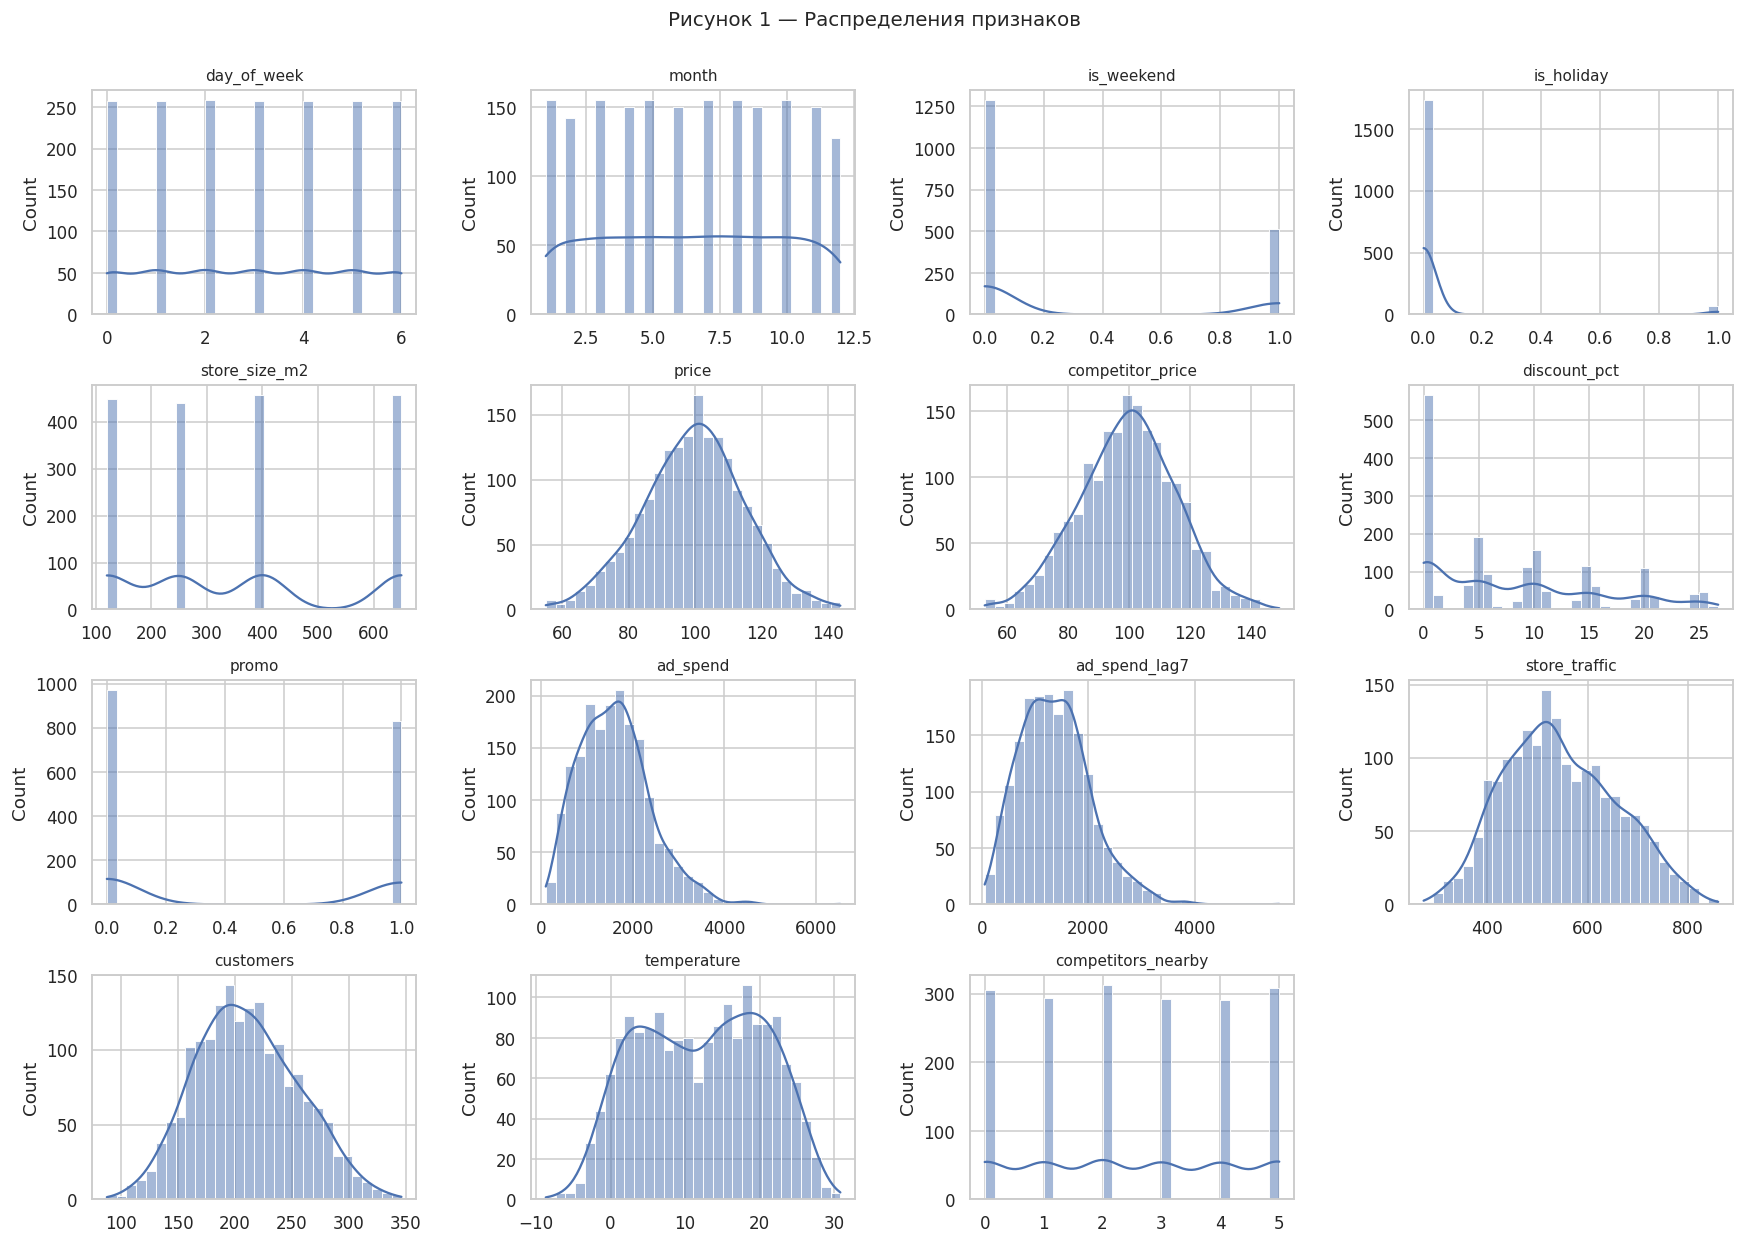

In [72]:
# --- Гистограммы распределения всех признаков ---
cols = feature_cols_raw
n_cols = 4
n_rows = int(np.ceil(len(cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.8 * n_rows))
axes = np.array(axes).ravel()
for ax, c in zip(axes, cols):
    sns.histplot(df_raw[c].dropna(), bins=30, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(c, fontsize=10)
    ax.set_xlabel("")
for ax in axes[len(cols):]:
    ax.axis("off")
fig.suptitle("Рисунок 1 — Распределения признаков", y=1.005, fontsize=13)
plt.tight_layout()
plt.show()

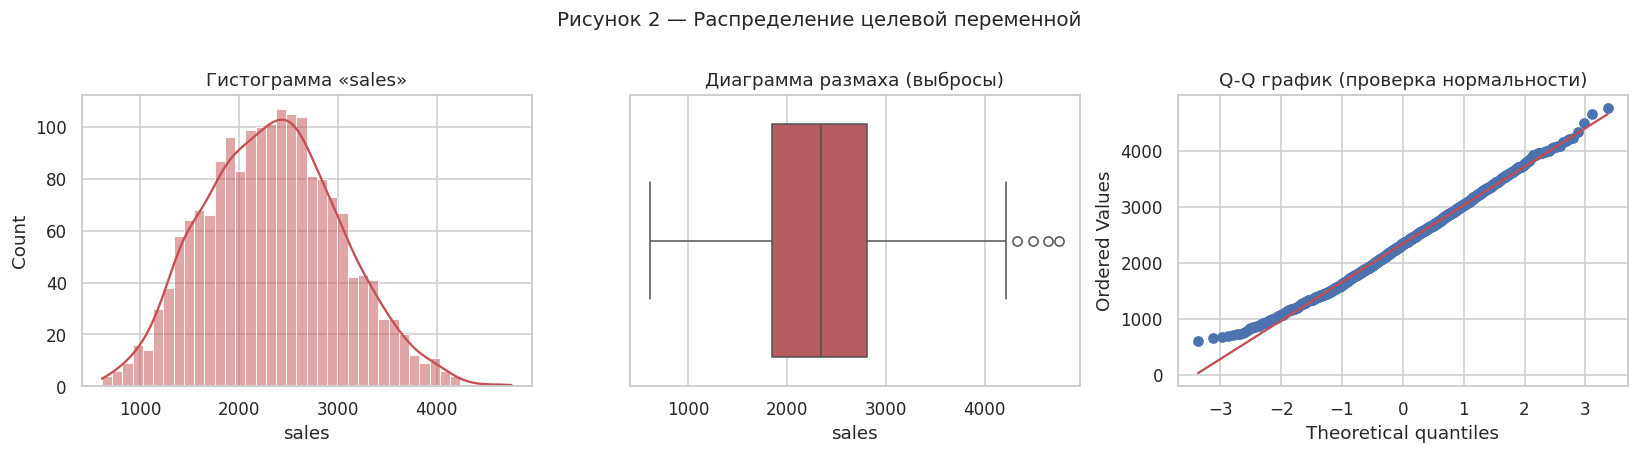

Среднее:            2,343.23
Медиана:            2,340.32
Стандартное откл.:  686.54
Коэф. асимметрии:   0.184
Коэф. эксцесса:     -0.254


In [73]:
# --- Распределение целевой переменной ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_raw[TARGET], bins=40, kde=True, ax=ax[0], color="#C44E52")
ax[0].set_title(f"Гистограмма «{TARGET}»")
sns.boxplot(x=df_raw[TARGET], ax=ax[1], color="#C44E52")
ax[1].set_title("Диаграмма размаха (выбросы)")
from scipy import stats as _st
_st.probplot(df_raw[TARGET].dropna(), dist="norm", plot=ax[2])
ax[2].set_title("Q-Q график (проверка нормальности)")
fig.suptitle("Рисунок 2 — Распределение целевой переменной", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Среднее:            {df_raw[TARGET].mean():,.2f}")
print(f"Медиана:            {df_raw[TARGET].median():,.2f}")
print(f"Стандартное откл.:  {df_raw[TARGET].std():,.2f}")
print(f"Коэф. асимметрии:   {df_raw[TARGET].skew():.3f}")
print(f"Коэф. эксцесса:     {df_raw[TARGET].kurtosis():.3f}")

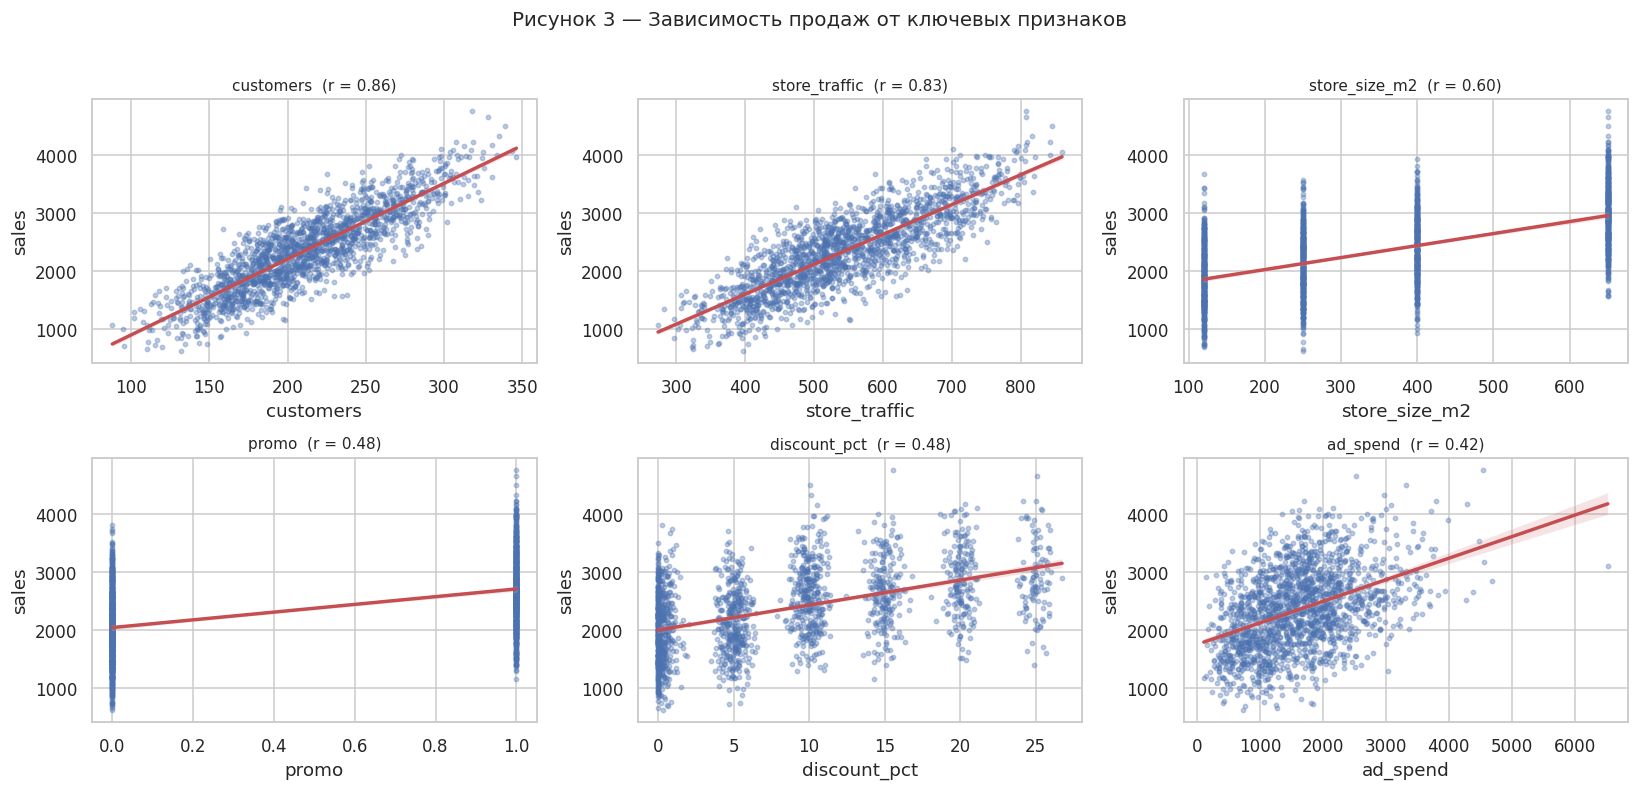

Корреляция признаков с целевой переменной (по убыванию |r|):
                         r
customers           0.8615
store_traffic       0.8332
store_size_m2       0.5956
promo               0.4837
discount_pct        0.4834
ad_spend            0.4162
is_weekend          0.1898
day_of_week         0.1336
is_holiday          0.1200
price              -0.0655
competitor_price   -0.0650
competitors_nearby -0.0599
ad_spend_lag7       0.0431
month               0.0191
temperature        -0.0038


In [74]:
# --- Зависимость целевой переменной от наиболее связанных признаков ---
corr_t = df_raw[feature_cols_raw + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
top = corr_t.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), top):
    sns.regplot(x=df_raw[c], y=df_raw[TARGET], ax=ax,
                scatter_kws=dict(s=8, alpha=0.35), line_kws=dict(color="#C44E52"))
    ax.set_title(f"{c}  (r = {corr_t[c]:.2f})", fontsize=10)
fig.suptitle("Рисунок 3 — Зависимость продаж от ключевых признаков", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("Корреляция признаков с целевой переменной (по убыванию |r|):")
print(corr_t.reindex(corr_t.abs().sort_values(ascending=False).index).to_frame("r"))

---
## 4. Подготовка данных

Этапы предобработки:

1. **Удаление служебных столбцов** (даты, идентификаторы) — из даты предварительно извлечены
   календарные признаки (`month`, `day_of_week`, `is_weekend`).
2. **Удаление пропусков** — согласно постановке задачи строки с пропусками удаляются
   (`dropna`); их доля мала (≈2.5 %), поэтому потеря информации незначительна.
3. **Кодирование категориальных переменных** — методом One-Hot Encoding (`pd.get_dummies`)
   для столбцов типа `object`/`category` с небольшим числом уникальных значений.
4. **Разделение выборки** на обучающую и тестовую в соотношении **80/20** (`train_test_split`).
5. **Стандартизация признаков** (`StandardScaler`, приведение к μ = 0, σ = 1) — обязательна,
   так как масштабы признаков различаются на порядки (например, `promo` ∈ {0,1},
   а `ad_spend` — тысячи у.е.), а LASSO и Ridge штрафуют коэффициенты и чувствительны к масштабу.
   Скейлер обучается **только на train** и включён в `Pipeline`, что исключает утечку данных
   при кросс-валидации.

In [75]:
# --- 4.1. Очистка данных ---
df = df_raw.copy()

# служебные столбцы: даты и идентификаторы
drop_cols = [c for c in df.columns
             if np.issubdtype(df[c].dtype, np.datetime64)
             or c.lower() in {"id", "row id", "index", "unnamed: 0"}]
if drop_cols:
    print("Удаляются служебные столбцы:", drop_cols)
    df = df.drop(columns=drop_cols)

# кодирование категориальных признаков (One-Hot)
cat_cols = [c for c in df.select_dtypes(include=["object", "category"]).columns
            if c != TARGET and df[c].nunique() <= 15]
high_card = [c for c in df.select_dtypes(include=["object", "category"]).columns
             if c not in cat_cols and c != TARGET]
if high_card:
    print("Удаляются категориальные признаки с высокой кардинальностью:", high_card)
    df = df.drop(columns=high_card)
if cat_cols:
    print("One-Hot кодирование:", cat_cols)
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)
else:
    print("Категориальных признаков для кодирования нет.")

# удаление пропусков
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"\nУдалено строк с пропусками: {before - len(df)}  (осталось {len(df)})")

X = df.drop(columns=[TARGET]).astype(float)
y = df[TARGET].astype(float)
FEATURES = X.columns.tolist()
print(f"Итоговая матрица признаков X: {X.shape}, вектор y: {y.shape}")

Удаляются служебные столбцы: ['date']
Категориальных признаков для кодирования нет.

Удалено строк с пропусками: 45  (осталось 1755)
Итоговая матрица признаков X: (1755, 15), вектор y: (1755,)


In [76]:
# --- 4.2. Разделение на обучающую и тестовую выборки (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"Обучающая выборка: {X_train.shape[0]} наблюдений ({(1 - TEST_SIZE) * 100:.0f}%)")
print(f"Тестовая выборка:  {X_test.shape[0]} наблюдений ({TEST_SIZE * 100:.0f}%)")
print(f"\nСреднее y_train = {y_train.mean():,.2f} | среднее y_test = {y_test.mean():,.2f}"
      "  -> выборки однородны")

Обучающая выборка: 1404 наблюдений (80%)
Тестовая выборка:  351 наблюдений (20%)

Среднее y_train = 2,353.27 | среднее y_test = 2,304.81  -> выборки однородны


In [77]:
# --- 4.3. Демонстрация стандартизации ---
scaler_demo = StandardScaler().fit(X_train)
X_train_std = pd.DataFrame(scaler_demo.transform(X_train), columns=FEATURES)

comparison = pd.DataFrame({
    "среднее до": X_train.mean(),
    "СКО до": X_train.std(),
    "среднее после": X_train_std.mean(),
    "СКО после": X_train_std.std(),
})
print("Эффект стандартизации (StandardScaler):")
comparison.head(12)

Эффект стандартизации (StandardScaler):


,среднее до,СКО до,среднее после,СКО после
day_of_week,3.0370,1.9918,-0.0000,1.0004
month,6.4395,3.4112,0.0000,1.0004
is_weekend,0.2913,0.4545,0.0000,1.0004
is_holiday,0.0370,0.1889,-0.0000,1.0004
store_size_m2,356.5598,198.4406,0.0000,1.0004
price,99.5855,15.3034,0.0000,1.0004
competitor_price,99.5749,15.7818,0.0000,1.0004
discount_pct,8.2100,7.6776,0.0000,1.0004
promo,0.4736,0.4995,-0.0000,1.0004
ad_spend,"1,615.1737",778.3975,-0.0000,1.0004


---
## 5. Корреляционный анализ и проверка мультиколлинеарности

**Мультиколлинеарность** — наличие сильной линейной зависимости между признаками.
Она не ухудшает прогноз напрямую, но делает оценки коэффициентов МНК неустойчивыми
(матрица $X^TX$ близка к вырожденной, дисперсия коэффициентов резко растёт), из-за чего
модель теряет интерпретируемость.

Диагностика проводится двумя способами:

* **корреляционная матрица** — пары признаков с $|r| > 0.8$;
* **коэффициент вздутия дисперсии (VIF)**:
$$VIF_j = \frac{1}{1 - R_j^2},$$
где $R_j^2$ — коэффициент детерминации регрессии признака $x_j$ на все остальные признаки.
Интерпретация: VIF < 5 — мультиколлинеарности нет, 5 ≤ VIF < 10 — умеренная,
**VIF ≥ 10 — сильная мультиколлинеарность**.

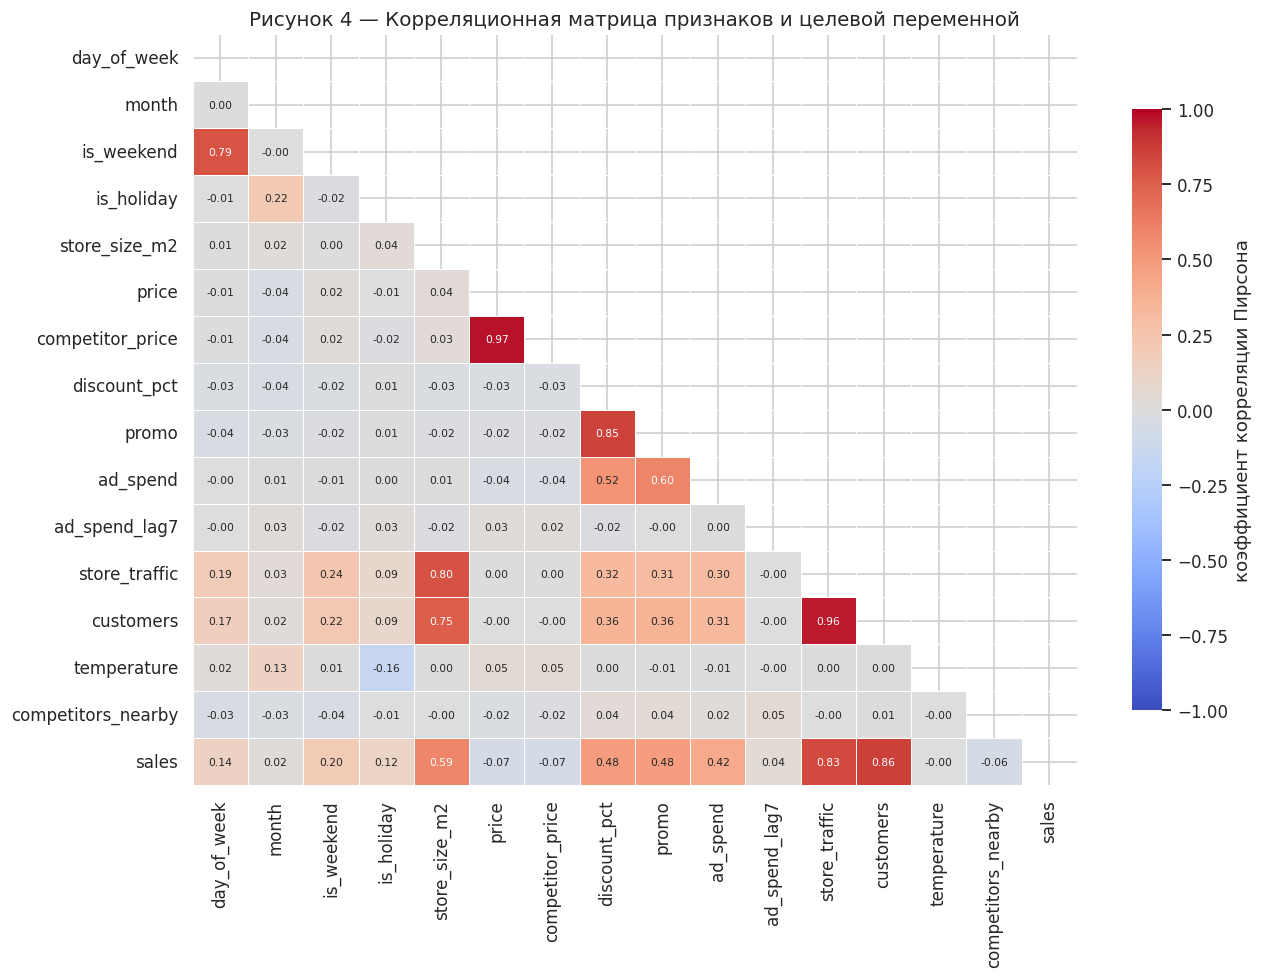

In [78]:
# --- 5.1. Корреляционная матрица ---
corr = df[FEATURES + [TARGET]].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=.5, annot_kws={"size": 7},
            cbar_kws={"shrink": .8, "label": "коэффициент корреляции Пирсона"})
plt.title("Рисунок 4 — Корреляционная матрица признаков и целевой переменной", fontsize=13)
plt.tight_layout()
plt.show()

In [79]:
# --- 5.2. Пары сильно коррелированных признаков ---
c = corr.loc[FEATURES, FEATURES].abs()
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
          .stack().sort_values(ascending=False))
strong = pairs[pairs > 0.8]
print("Пары признаков с |r| > 0.8:")
if len(strong):
    for (a, b), v in strong.items():
        print(f"  {a:>20s}  <->  {b:<20s}  r = {corr.loc[a, b]:+.3f}")
else:
    print("  таких пар не обнаружено")

Пары признаков с |r| > 0.8:
                 price  <->  competitor_price      r = +0.973
         store_traffic  <->  customers             r = +0.959
          discount_pct  <->  promo                 r = +0.854
         store_size_m2  <->  store_traffic         r = +0.803


In [80]:
# --- 5.3. Расчёт VIF ---
def calc_vif(X_df: pd.DataFrame) -> pd.DataFrame:
    # VIF_j = 1 / (1 - R2_j), где R2_j - коэффициент детерминации регрессии
    # признака x_j на все остальные признаки.
    Xs = StandardScaler().fit_transform(X_df)
    rows = []
    for i, col in enumerate(X_df.columns):
        y_i = Xs[:, i]
        X_i = np.delete(Xs, i, axis=1)
        r2 = LinearRegression().fit(X_i, y_i).score(X_i, y_i)
        vif = np.inf if r2 >= 1 - 1e-12 else 1.0 / (1.0 - r2)
        rows.append({"Признак": col, "R2_j": r2, "VIF": vif})
    return (pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True))


vif_before = calc_vif(X)


def vif_level(v):
    return "сильная" if v >= 10 else ("умеренная" if v >= 5 else "нет")


vif_before["Мультиколлинеарность"] = vif_before["VIF"].map(vif_level)
vif_before

,Признак,R2_j,VIF,Мультиколлинеарность
0,price,0.9467,18.7451,сильная
1,competitor_price,0.9466,18.7148,сильная
2,store_traffic,0.9448,18.1268,сильная
3,customers,0.9247,13.2884,сильная
4,store_size_m2,0.8059,5.1532,умеренная
5,promo,0.7658,4.2694,нет
6,discount_pct,0.7566,4.1090,нет
7,is_weekend,0.6753,3.0796,нет
8,day_of_week,0.6274,2.6839,нет
9,ad_spend,0.4135,1.7050,нет


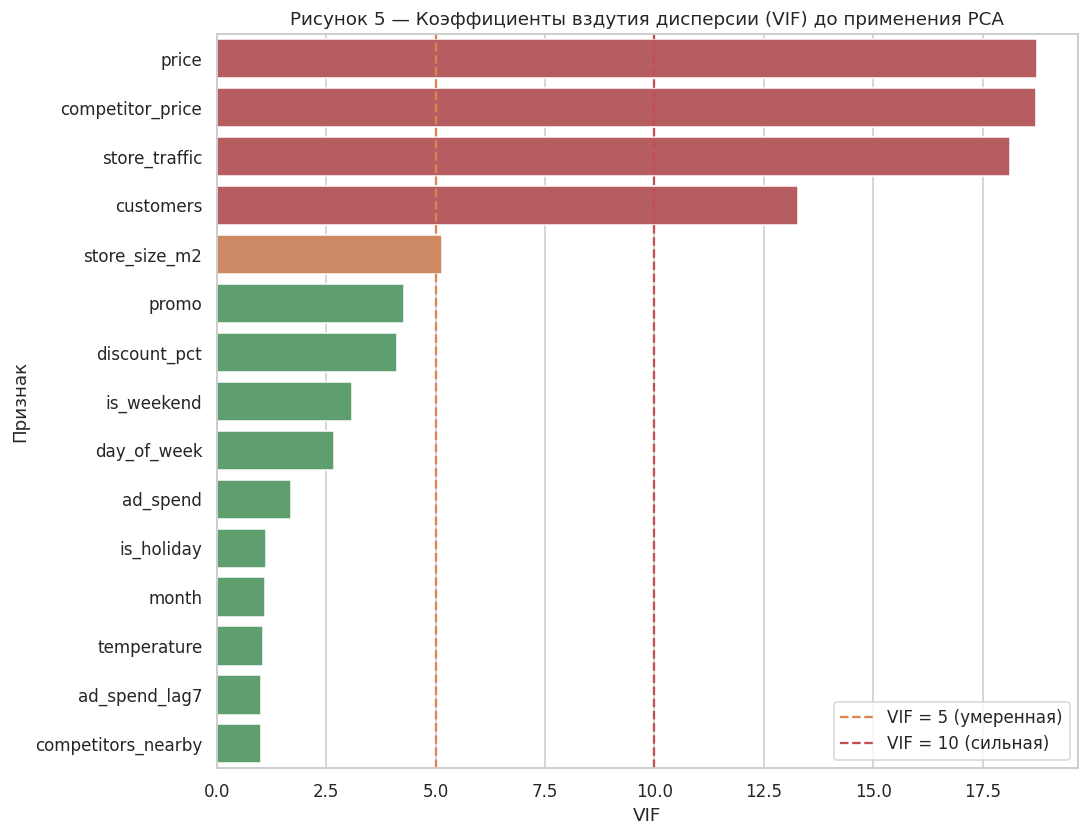

Признаков с сильной мультиколлинеарностью (VIF >= 10): 4
Признаков с умеренной мультиколлинеарностью (5 <= VIF < 10): 1
Максимальный VIF: 18.75 (price)


In [81]:
# --- 5.4. График VIF ---
plt.figure(figsize=(10, 0.38 * len(vif_before) + 2))
colors = ["#C44E52" if v >= 10 else "#DD8452" if v >= 5 else "#55A868"
          for v in vif_before["VIF"]]
sns.barplot(data=vif_before, y="Признак", x="VIF", palette=colors)
plt.axvline(5, ls="--", c="#DD8452", label="VIF = 5 (умеренная)")
plt.axvline(10, ls="--", c="#C44E52", label="VIF = 10 (сильная)")
plt.title("Рисунок 5 — Коэффициенты вздутия дисперсии (VIF) до применения PCA")
plt.legend()
plt.tight_layout()
plt.show()

n_bad = int((vif_before["VIF"] >= 10).sum())
n_mid = int(((vif_before["VIF"] >= 5) & (vif_before["VIF"] < 10)).sum())
print(f"Признаков с сильной мультиколлинеарностью (VIF >= 10): {n_bad}")
print(f"Признаков с умеренной мультиколлинеарностью (5 <= VIF < 10): {n_mid}")
print(f"Максимальный VIF: {vif_before['VIF'].max():.2f} "
      f"({vif_before.iloc[0]['Признак']})")

**Вывод по п. 5.** В данных присутствует выраженная мультиколлинеарность: несколько признаков
имеют VIF ≥ 10 и попарные корреляции, близкие к единице. Экономически это объяснимо:
цена конкурента формируется с оглядкой на нашу цену, число покупателей есть фиксированная доля
трафика магазина, а рекламный бюджет меняется плавно от недели к неделе. Такие признаки дублируют
друг друга, поэтому оценки коэффициентов обычного МНК будут неустойчивыми — это обосновывает
применение регуляризации (LASSO, Ridge) и метода главных компонент (раздел 7).

---
## 6. Построение регрессионных моделей на исходных признаках

Строятся три модели, каждая — в составе `Pipeline` со стандартизацией:

| Модель | Минимизируемый функционал | Назначение |
|---|---|---|
| Линейная (МНК) | $\|y - X\beta\|^2$ | базовая модель |
| LASSO (L1) | $\|y - X\beta\|^2 + \alpha\|\beta\|_1$ | отбор признаков, зануление коэффициентов |
| Гребневая / Ridge (L2) | $\|y - X\beta\|^2 + \alpha\|\beta\|_2^2$ | подавление мультиколлинеарности |

Гиперпараметр $\alpha$ подбирается по сетке из 40 значений (логарифмическая шкала $10^{-3}..10^{3}$)
методом `GridSearchCV` с 5-блочной кросс-валидацией на обучающей выборке.

**Метрики качества:**
* $RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat y_i)^2}$ — в единицах целевой переменной, чем меньше, тем лучше;
* $R^2 = 1 - \frac{\sum (y_i-\hat y_i)^2}{\sum (y_i-\bar y)^2}$ — доля объяснённой дисперсии, чем ближе к 1, тем лучше;
* $MAPE = \frac{100\%}{n}\sum \left|\frac{y_i - \hat y_i}{y_i}\right|$ — средняя относительная ошибка.

In [82]:
# --- 6.1. Вспомогательные функции ---
ALPHAS = np.logspace(-3, 3, 40)
CV = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def compute_metrics(y_true, y_pred) -> dict:
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "MAPE_%": float(mean_absolute_percentage_error(y_true, y_pred) * 100),
    }


def make_model(kind: str, n_components=None):
    # Собирает Pipeline: стандартизация -> [PCA] -> регрессия.
    # Для LASSO/Ridge оборачивает модель в GridSearchCV для подбора alpha.
    steps = [("scaler", StandardScaler())]
    if n_components is not None:
        steps.append(("pca", PCA(n_components=n_components, random_state=RANDOM_STATE)))

    if kind == "Линейная":
        steps.append(("model", LinearRegression()))
        return Pipeline(steps), None
    if kind == "LASSO":
        steps.append(("model", Lasso(max_iter=50000, random_state=RANDOM_STATE)))
    elif kind == "Ridge":
        steps.append(("model", Ridge(random_state=RANDOM_STATE)))
    else:
        raise ValueError(kind)
    gs = GridSearchCV(Pipeline(steps), {"model__alpha": ALPHAS},
                      cv=CV, scoring="neg_root_mean_squared_error", n_jobs=-1)
    return gs, "grid"


def fit_and_evaluate(kind: str, X_tr, y_tr, X_te, y_te, n_components=None, tag=""):
    # Обучает модель, считает CV-RMSE на train и метрики на тестовой выборке.
    est, grid = make_model(kind, n_components)
    est.fit(X_tr, y_tr)
    best = est.best_estimator_ if grid else est
    alpha = est.best_params_["model__alpha"] if grid else np.nan

    cv_rmse = -cross_val_score(best, X_tr, y_tr, cv=CV,
                               scoring="neg_root_mean_squared_error").mean()
    cv_r2 = cross_val_score(best, X_tr, y_tr, cv=CV, scoring="r2").mean()

    res = compute_metrics(y_te, best.predict(X_te))
    res.update({"Модель": kind + tag, "alpha": alpha,
                "CV_RMSE": cv_rmse, "CV_R2": cv_r2,
                "RMSE_train": compute_metrics(y_tr, best.predict(X_tr))["RMSE"]})
    return best, res

In [83]:
# --- 6.2. Обучение трёх моделей на исходных признаках ---
models_raw, results_raw = {}, []
for kind in ["Линейная", "LASSO", "Ridge"]:
    model, res = fit_and_evaluate(kind, X_train, y_train, X_test, y_test)
    models_raw[kind] = model
    results_raw.append(res)
    a = "—" if np.isnan(res["alpha"]) else f"{res['alpha']:.4f}"
    print(f"{kind:>9s}: alpha = {a:>8s} | CV-RMSE = {res['CV_RMSE']:8.2f} | "
          f"тест RMSE = {res['RMSE']:8.2f} | R² = {res['R2']:.4f} | MAPE = {res['MAPE_%']:.2f}%")

cols_order = ["Модель", "alpha", "CV_RMSE", "CV_R2", "RMSE_train", "RMSE", "R2", "MAPE_%"]
df_raw_res = pd.DataFrame(results_raw)[cols_order]
print("\nТаблица 1 — Метрики моделей на исходных признаках")
df_raw_res

 Линейная: alpha =        — | CV-RMSE =   309.58 | тест RMSE =   307.46 | R² = 0.7781 | MAPE = 11.93%
    LASSO: alpha =   0.8377 | CV-RMSE =   309.51 | тест RMSE =   307.06 | R² = 0.7786 | MAPE = 11.93%
    Ridge: alpha =   3.4551 | CV-RMSE =   309.55 | тест RMSE =   307.41 | R² = 0.7781 | MAPE = 11.93%

Таблица 1 — Метрики моделей на исходных признаках


,Модель,alpha,CV_RMSE,CV_R2,RMSE_train,RMSE,R2,MAPE_%
0,Линейная,NaN,309.5821,0.7997,306.9260,307.4645,0.7781,11.9304
1,LASSO,0.8377,309.5108,0.7998,306.9999,307.0609,0.7786,11.9311
2,Ridge,3.4551,309.5503,0.7998,306.9444,307.4085,0.7781,11.9294


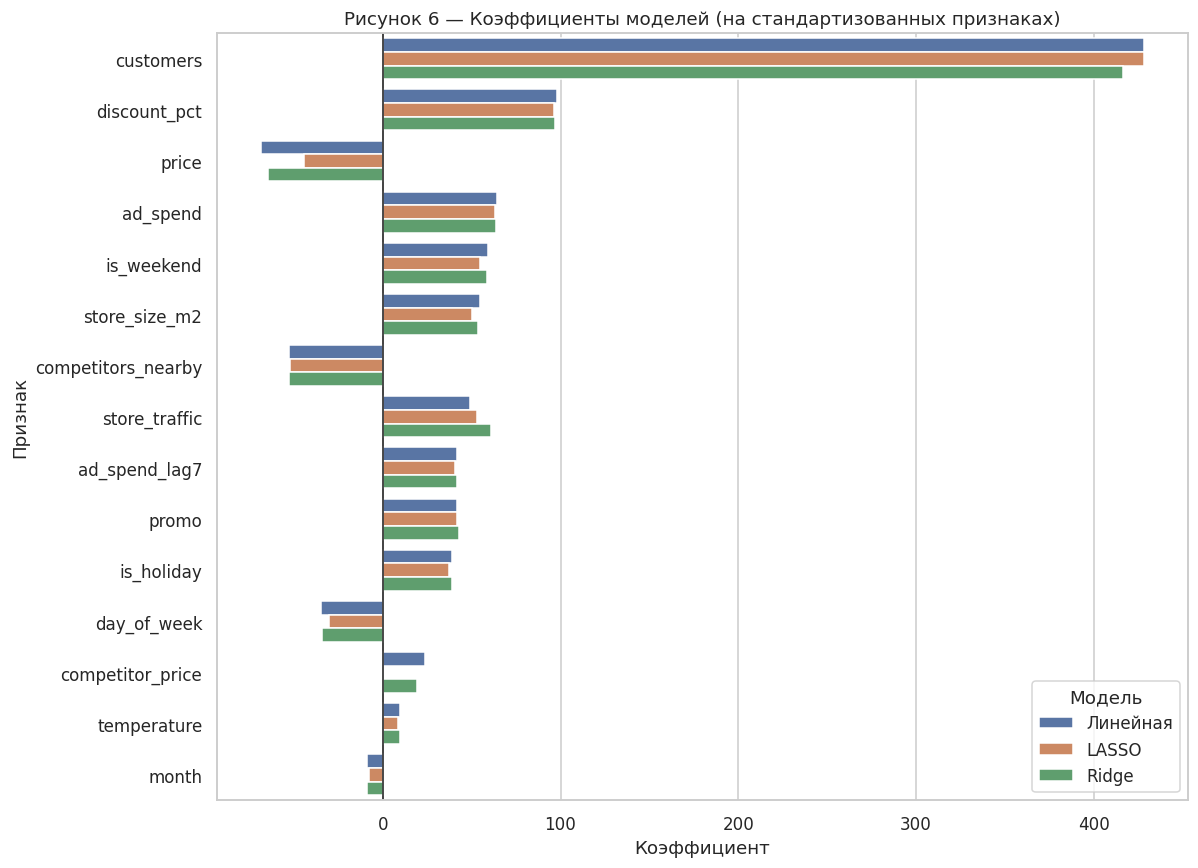

LASSO обнулил коэффициентов: 1 из 15


,Признак,Линейная,LASSO,Ridge
12,customers,428.2883,428.2093,416.7860
7,discount_pct,97.9632,96.5628,97.1597
5,price,-68.5401,-44.3183,-64.3589
9,ad_spend,64.2482,63.0390,63.9205
2,is_weekend,59.4533,54.4352,58.7852
4,store_size_m2,54.4910,50.2393,53.7078
14,competitors_nearby,-53.0167,-52.1406,-52.8395
11,store_traffic,49.0386,53.1796,60.6106
10,ad_spend_lag7,41.8683,40.6835,41.7752
8,promo,41.7044,41.6349,42.9631


In [84]:
# --- 6.3. Коэффициенты моделей ---
coef_tbl = pd.DataFrame({"Признак": FEATURES})
for kind, m in models_raw.items():
    coef_tbl[kind] = m.named_steps["model"].coef_
coef_tbl["|Линейная|"] = coef_tbl["Линейная"].abs()
coef_tbl = coef_tbl.sort_values("|Линейная|", ascending=False).drop(columns="|Линейная|")

plt.figure(figsize=(11, 0.4 * len(FEATURES) + 2))
melted = coef_tbl.melt(id_vars="Признак", var_name="Модель", value_name="Коэффициент")
sns.barplot(data=melted, y="Признак", x="Коэффициент", hue="Модель")
plt.axvline(0, c="k", lw=1)
plt.title("Рисунок 6 — Коэффициенты моделей (на стандартизованных признаках)")
plt.tight_layout()
plt.show()

zeroed = int((np.abs(coef_tbl["LASSO"]) < 1e-8).sum())
print(f"LASSO обнулил коэффициентов: {zeroed} из {len(FEATURES)}")
coef_tbl.head(12)

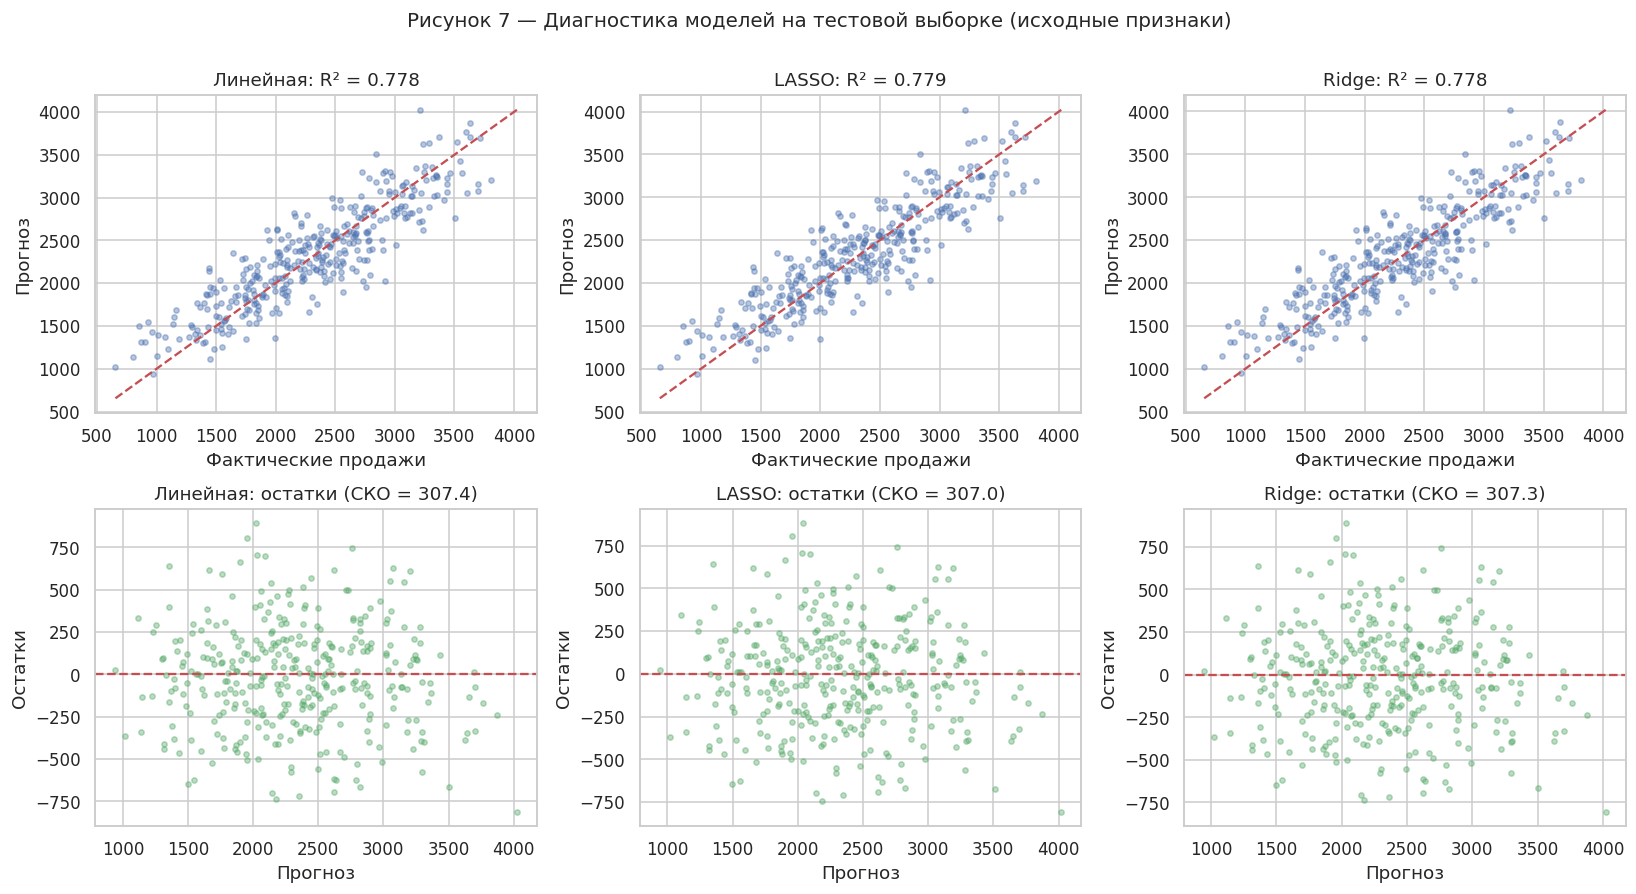

In [85]:
# --- 6.4. Диагностика качества: факт vs прогноз и остатки ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, (kind, m) in enumerate(models_raw.items()):
    pred = m.predict(X_test)
    resid = y_test - pred

    ax = axes[0, j]
    ax.scatter(y_test, pred, s=12, alpha=0.4, color="#4C72B0")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "--", c="#C44E52")
    ax.set_xlabel("Фактические продажи"); ax.set_ylabel("Прогноз")
    ax.set_title(f"{kind}: R² = {r2_score(y_test, pred):.3f}")

    ax = axes[1, j]
    ax.scatter(pred, resid, s=12, alpha=0.4, color="#55A868")
    ax.axhline(0, ls="--", c="#C44E52")
    ax.set_xlabel("Прогноз"); ax.set_ylabel("Остатки")
    ax.set_title(f"{kind}: остатки (СКО = {resid.std():.1f})")
fig.suptitle("Рисунок 7 — Диагностика моделей на тестовой выборке (исходные признаки)",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

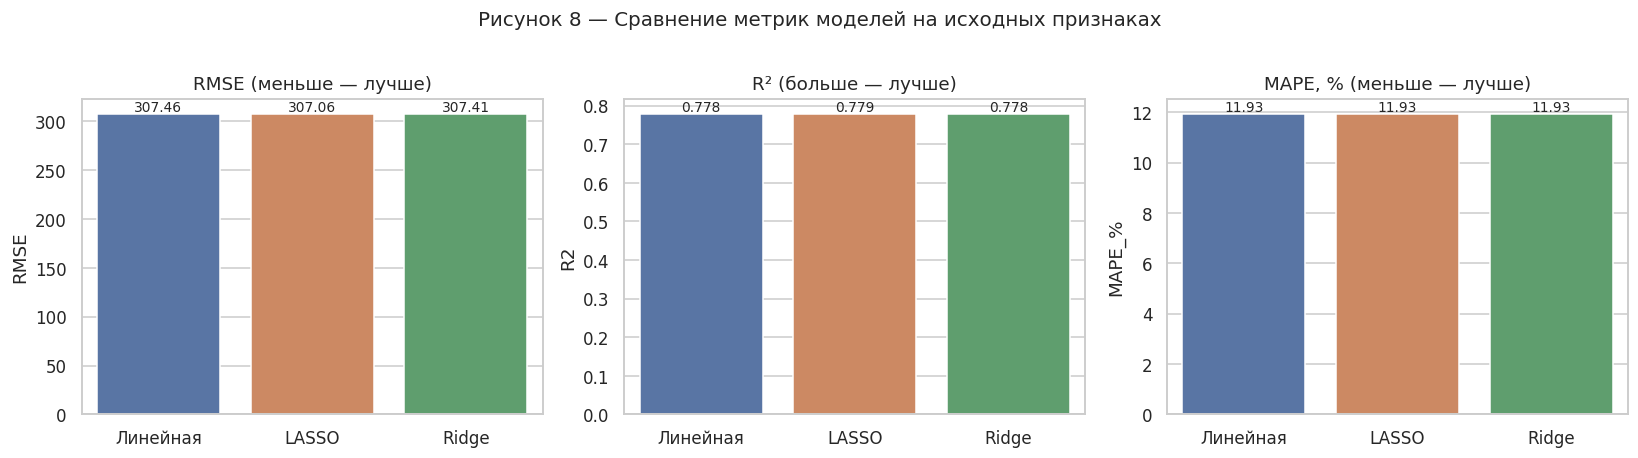

In [86]:
# --- 6.5. Метрики в графическом виде ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes, ["RMSE", "R2", "MAPE_%"],
                             ["RMSE (меньше — лучше)", "R² (больше — лучше)",
                              "MAPE, % (меньше — лучше)"]):
    sns.barplot(data=df_raw_res, x="Модель", y=metric, ax=ax, palette="deep")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}" if metric == "R2" else f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.set_title(title); ax.set_xlabel("")
fig.suptitle("Рисунок 8 — Сравнение метрик моделей на исходных признаках", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Устранение мультиколлинеарности методом главных компонент (PCA)

**Идея метода.** PCA переходит от исходных признаков к их линейным комбинациям — главным
компонентам, которые **ортогональны** (некоррелированы) друг другу и упорядочены по величине
объяснённой дисперсии. Ортогональность означает, что корреляции между новыми признаками равны
нулю, а значит VIF всех компонент равен 1 — мультиколлинеарность устраняется полностью.
Отбросив компоненты с малой дисперсией, мы дополнительно снижаем размерность и уровень шума.

**Важно:** PCA чувствителен к масштабу, поэтому перед разложением обязательно выполняется
**стандартизация** (`StandardScaler`). Скейлер и PCA обучаются только на обучающей выборке
(внутри `Pipeline`), к тестовой выборке применяется уже обученное преобразование.

Число компонент выбирается по критерию **накопленной объяснённой дисперсии ≥ 95 %**;
дополнительно строится **график каменистой осыпи** (scree plot) и применяется критерий Кайзера
(собственные значения > 1).

In [87]:
# --- 7.1. Разложение на главные компоненты (обучение на train) ---
scaler_pca = StandardScaler().fit(X_train)
X_train_sc = scaler_pca.transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_sc)
evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)
eigvals = pca_full.explained_variance_

VAR_THRESHOLD = 0.95
N_COMPONENTS = int(np.searchsorted(cum_evr, VAR_THRESHOLD) + 1)
n_kaiser = int((eigvals > 1).sum())

pca_tbl = pd.DataFrame({
    "Компонента": [f"PC{i+1}" for i in range(len(evr))],
    "Собственное значение": eigvals,
    "Доля дисперсии, %": evr * 100,
    "Накопленная доля, %": cum_evr * 100,
})
print(f"Выбрано компонент по критерию 95% дисперсии: {N_COMPONENTS} "
      f"(из {X_train.shape[1]} исходных признаков)")
print(f"Критерий Кайзера (собств. значение > 1) даёт: {n_kaiser} компонент")
print(f"Снижение размерности: {X_train.shape[1]} -> {N_COMPONENTS} "
      f"({(1 - N_COMPONENTS / X_train.shape[1]) * 100:.1f}% признаков отброшено)")
pca_tbl

Выбрано компонент по критерию 95% дисперсии: 10 (из 15 исходных признаков)
Критерий Кайзера (собств. значение > 1) даёт: 7 компонент
Снижение размерности: 15 -> 10 (33.3% признаков отброшено)


,Компонента,Собственное значение,"Доля дисперсии, %","Накопленная доля, %"
0,PC1,3.3079,22.0367,22.0367
1,PC2,2.0863,13.8986,35.9353
2,PC3,1.9427,12.9418,48.8771
3,PC4,1.6340,10.8857,59.7628
4,PC5,1.2222,8.1425,67.9053
5,PC6,1.1145,7.4245,75.3298
6,PC7,1.0377,6.9131,82.2430
7,PC8,0.9350,6.2290,88.4720
8,PC9,0.6658,4.4354,92.9073
9,PC10,0.5109,3.4034,96.3108


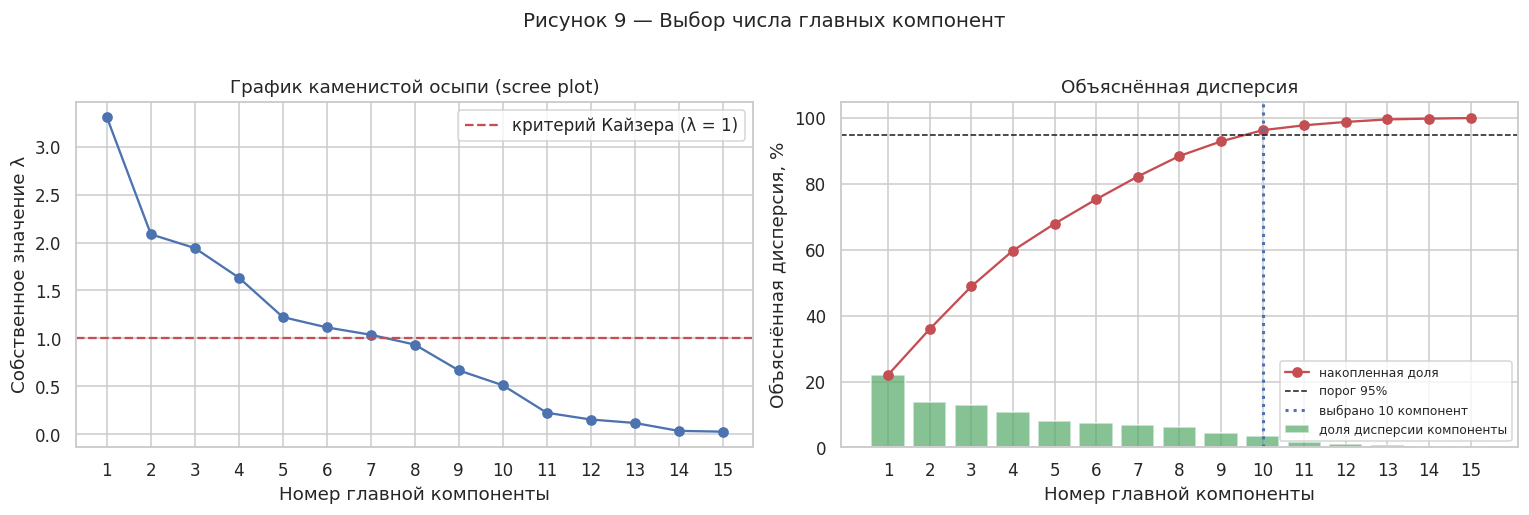

In [88]:
# --- 7.2. График каменистой осыпи (scree plot) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
xs = np.arange(1, len(evr) + 1)

axes[0].plot(xs, eigvals, "o-", color="#4C72B0")
axes[0].axhline(1, ls="--", c="#C44E52", label="критерий Кайзера (λ = 1)")
axes[0].set_xlabel("Номер главной компоненты")
axes[0].set_ylabel("Собственное значение λ")
axes[0].set_title("График каменистой осыпи (scree plot)")
axes[0].set_xticks(xs)
axes[0].legend()

axes[1].bar(xs, evr * 100, color="#55A868", alpha=.7, label="доля дисперсии компоненты")
axes[1].plot(xs, cum_evr * 100, "o-", color="#C44E52", label="накопленная доля")
axes[1].axhline(95, ls="--", c="k", lw=1, label="порог 95%")
axes[1].axvline(N_COMPONENTS, ls=":", c="#4C72B0", lw=2,
                label=f"выбрано {N_COMPONENTS} компонент")
axes[1].set_xlabel("Номер главной компоненты")
axes[1].set_ylabel("Объяснённая дисперсия, %")
axes[1].set_title("Объяснённая дисперсия")
axes[1].set_xticks(xs)
axes[1].legend(fontsize=8)

fig.suptitle("Рисунок 9 — Выбор числа главных компонент", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

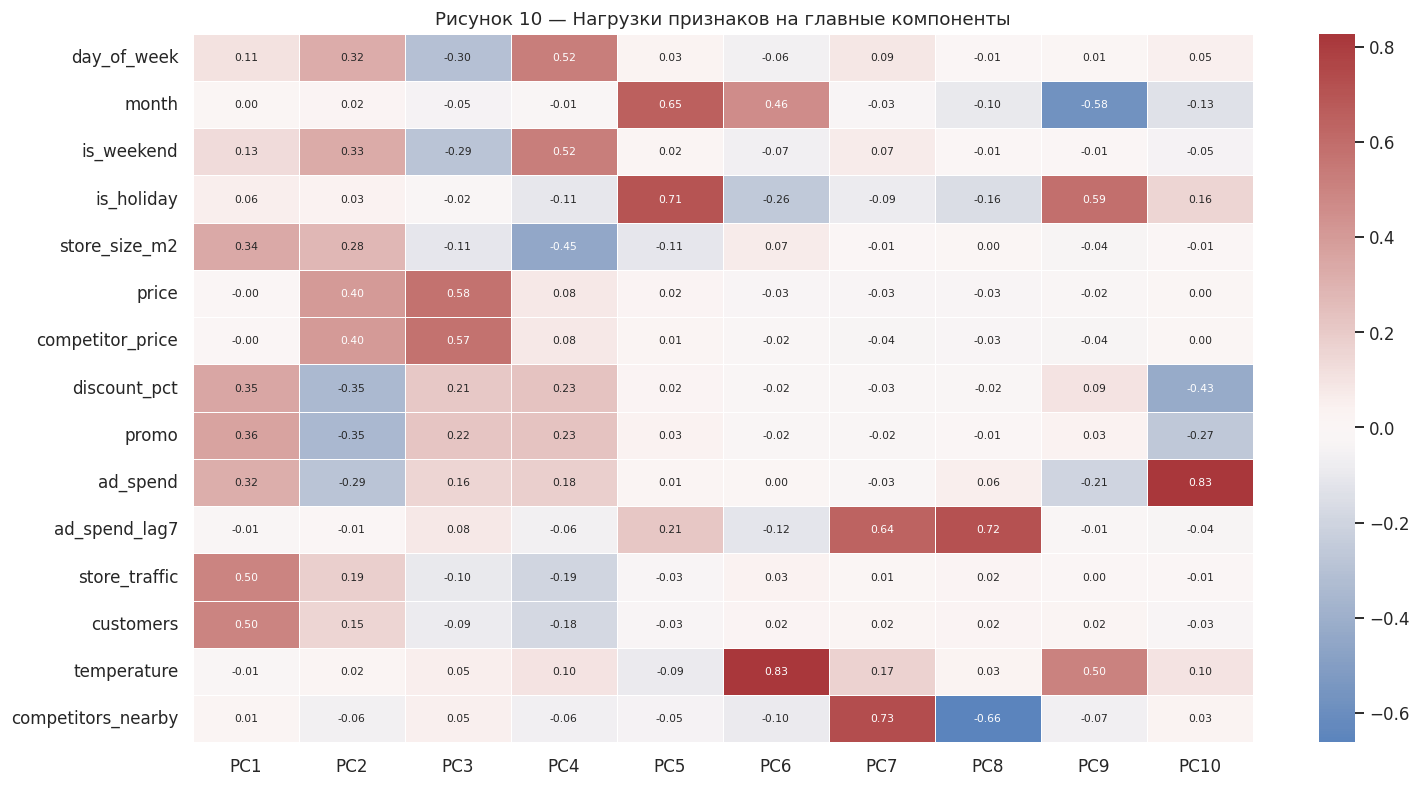

Наиболее влиятельные признаки первых трёх компонент:
  PC1: customers (+0.50), store_traffic (+0.50), promo (+0.36)
  PC2: competitor_price (+0.40), price (+0.40), promo (-0.35)
  PC3: price (+0.58), competitor_price (+0.57), day_of_week (-0.30)


In [89]:
# --- 7.3. Матрица нагрузок: вклад исходных признаков в компоненты ---
loadings = pd.DataFrame(
    pca_full.components_[:N_COMPONENTS].T,
    index=FEATURES,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)])

plt.figure(figsize=(1.0 * N_COMPONENTS + 4, 0.35 * len(FEATURES) + 2))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="vlag", center=0,
            annot_kws={"size": 7}, linewidths=.4)
plt.title("Рисунок 10 — Нагрузки признаков на главные компоненты")
plt.tight_layout()
plt.show()

print("Наиболее влиятельные признаки первых трёх компонент:")
for pc in loadings.columns[:3]:
    top3 = loadings[pc].abs().sort_values(ascending=False).head(3).index.tolist()
    print(f"  {pc}: " + ", ".join(f"{f} ({loadings.loc[f, pc]:+.2f})" for f in top3))

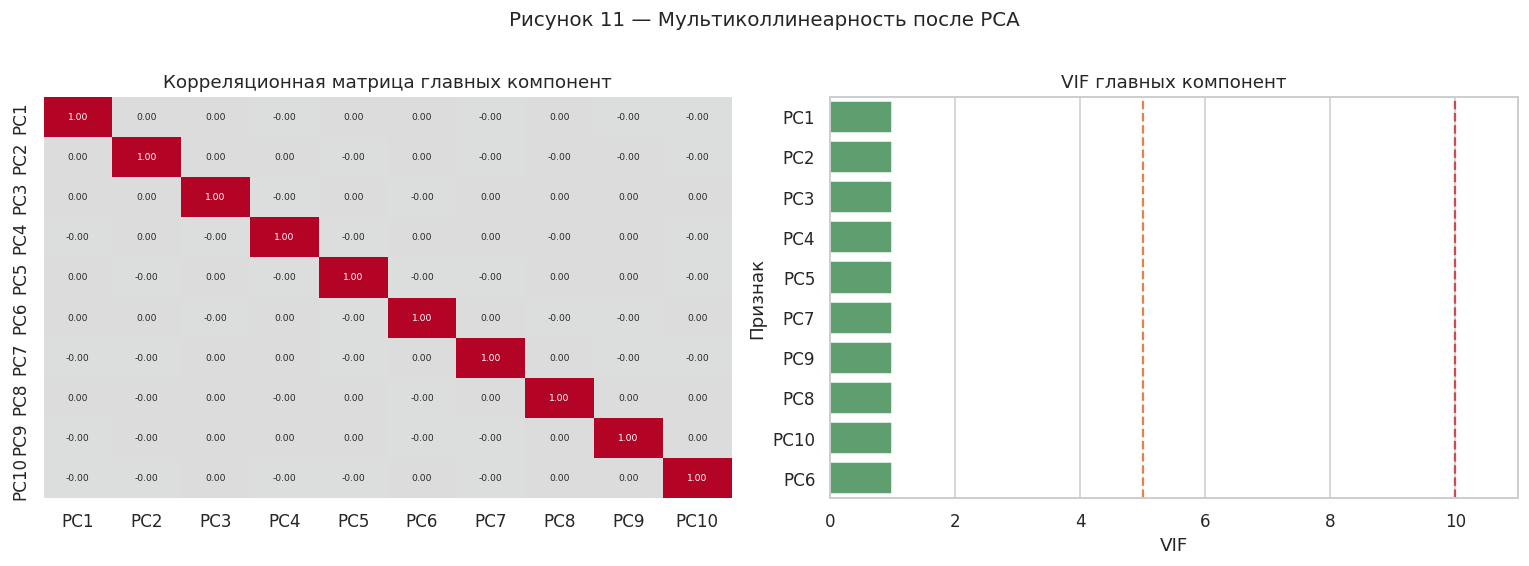

Максимальный VIF ДО PCA:       18.75
Максимальный VIF ПОСЛЕ PCA:     1.00
Все VIF равны 1.0 -> компоненты ортогональны, мультиколлинеарность устранена полностью.


In [90]:
# --- 7.4. Проверка: мультиколлинеарность после PCA устранена ---
X_pca_all = pd.DataFrame(
    PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
        .fit_transform(StandardScaler().fit_transform(X)),
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)])

vif_after = calc_vif(X_pca_all)
vif_after["Мультиколлинеарность"] = vif_after["VIF"].map(vif_level)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(X_pca_all.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 6}, cbar=False)
axes[0].set_title("Корреляционная матрица главных компонент")
sns.barplot(data=vif_after, y="Признак", x="VIF", ax=axes[1], color="#55A868")
axes[1].axvline(5, ls="--", c="#DD8452"); axes[1].axvline(10, ls="--", c="#C44E52")
axes[1].set_xlim(0, max(11, vif_after["VIF"].max() * 1.1))
axes[1].set_title("VIF главных компонент")
fig.suptitle("Рисунок 11 — Мультиколлинеарность после PCA", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Максимальный VIF ДО PCA:    {vif_before['VIF'].max():8.2f}")
print(f"Максимальный VIF ПОСЛЕ PCA: {vif_after['VIF'].max():8.2f}")
print("Все VIF равны 1.0 -> компоненты ортогональны, мультиколлинеарность устранена полностью.")

---
## 8. Повторное построение моделей на главных компонентах

Те же три модели (линейная, LASSO, гребневая) обучаются заново, но в качестве признаков
используются главные компоненты. PCA встроен в `Pipeline` после стандартизации, поэтому
преобразование корректно обучается на каждом фолде кросс-валидации отдельно.

In [91]:
# --- 8.1. Обучение моделей на главных компонентах ---
models_pca, results_pca = {}, []
for kind in ["Линейная", "LASSO", "Ridge"]:
    model, res = fit_and_evaluate(kind, X_train, y_train, X_test, y_test,
                                  n_components=N_COMPONENTS, tag=" + PCA")
    models_pca[kind] = model
    results_pca.append(res)
    a = "—" if np.isnan(res["alpha"]) else f"{res['alpha']:.4f}"
    print(f"{kind + ' + PCA':>16s}: alpha = {a:>8s} | CV-RMSE = {res['CV_RMSE']:8.2f} | "
          f"тест RMSE = {res['RMSE']:8.2f} | R² = {res['R2']:.4f} | MAPE = {res['MAPE_%']:.2f}%")

df_pca_res = pd.DataFrame(results_pca)[cols_order]
print("\nТаблица 2 — Метрики моделей на главных компонентах")
df_pca_res

  Линейная + PCA: alpha =        — | CV-RMSE =   322.14 | тест RMSE =   314.95 | R² = 0.7671 | MAPE = 12.17%
     LASSO + PCA: alpha =   2.4245 | CV-RMSE =   322.06 | тест RMSE =   314.76 | R² = 0.7674 | MAPE = 12.17%
     Ridge + PCA: alpha =  28.9427 | CV-RMSE =   322.11 | тест RMSE =   314.61 | R² = 0.7676 | MAPE = 12.17%

Таблица 2 — Метрики моделей на главных компонентах


,Модель,alpha,CV_RMSE,CV_R2,RMSE_train,RMSE,R2,MAPE_%
0,Линейная + PCA,NaN,322.1446,0.7831,319.7721,314.9457,0.7671,12.1684
1,LASSO + PCA,2.4245,322.0558,0.7833,319.8560,314.7642,0.7674,12.1732
2,Ridge + PCA,28.9427,322.1088,0.7832,319.8016,314.6051,0.7676,12.1747


In [92]:
# --- 8.2. Сводная таблица сравнения ---
compare = pd.concat([df_raw_res, df_pca_res], ignore_index=True)
compare["Признаки"] = ["Исходные"] * 3 + [f"ГК ({N_COMPONENTS} шт.)"] * 3
summary = compare[["Модель", "Признаки", "RMSE", "R2", "MAPE_%", "CV_RMSE"]]
print("Таблица 3 — Сравнение моделей до и после PCA (тестовая выборка)")
summary

Таблица 3 — Сравнение моделей до и после PCA (тестовая выборка)


,Модель,Признаки,RMSE,R2,MAPE_%,CV_RMSE
0,Линейная,Исходные,307.4645,0.7781,11.9304,309.5821
1,LASSO,Исходные,307.0609,0.7786,11.9311,309.5108
2,Ridge,Исходные,307.4085,0.7781,11.9294,309.5503
3,Линейная + PCA,ГК (10 шт.),314.9457,0.7671,12.1684,322.1446
4,LASSO + PCA,ГК (10 шт.),314.7642,0.7674,12.1732,322.0558
5,Ridge + PCA,ГК (10 шт.),314.6051,0.7676,12.1747,322.1088


In [93]:
# --- 8.3. Изменение метрик после перехода к главным компонентам ---
delta = pd.DataFrame({
    "Модель": ["Линейная", "LASSO", "Ridge"],
    "RMSE до": df_raw_res["RMSE"].values,
    "RMSE после": df_pca_res["RMSE"].values,
    "ΔRMSE, %": (df_pca_res["RMSE"].values / df_raw_res["RMSE"].values - 1) * 100,
    "R² до": df_raw_res["R2"].values,
    "R² после": df_pca_res["R2"].values,
    "ΔR²": df_pca_res["R2"].values - df_raw_res["R2"].values,
    "MAPE до, %": df_raw_res["MAPE_%"].values,
    "MAPE после, %": df_pca_res["MAPE_%"].values,
    "ΔMAPE, п.п.": df_pca_res["MAPE_%"].values - df_raw_res["MAPE_%"].values,
})
print("Таблица 4 — Изменение метрик после PCA")
delta

Таблица 4 — Изменение метрик после PCA


,Модель,RMSE до,RMSE после,"ΔRMSE, %",R² до,R² после,ΔR²,"MAPE до, %","MAPE после, %","ΔMAPE, п.п."
0,Линейная,307.4645,314.9457,2.4332,0.7781,0.7671,-0.0109,11.9304,12.1684,0.2380
1,LASSO,307.0609,314.7642,2.5087,0.7786,0.7674,-0.0112,11.9311,12.1732,0.2422
2,Ridge,307.4085,314.6051,2.3410,0.7781,0.7676,-0.0105,11.9294,12.1747,0.2453


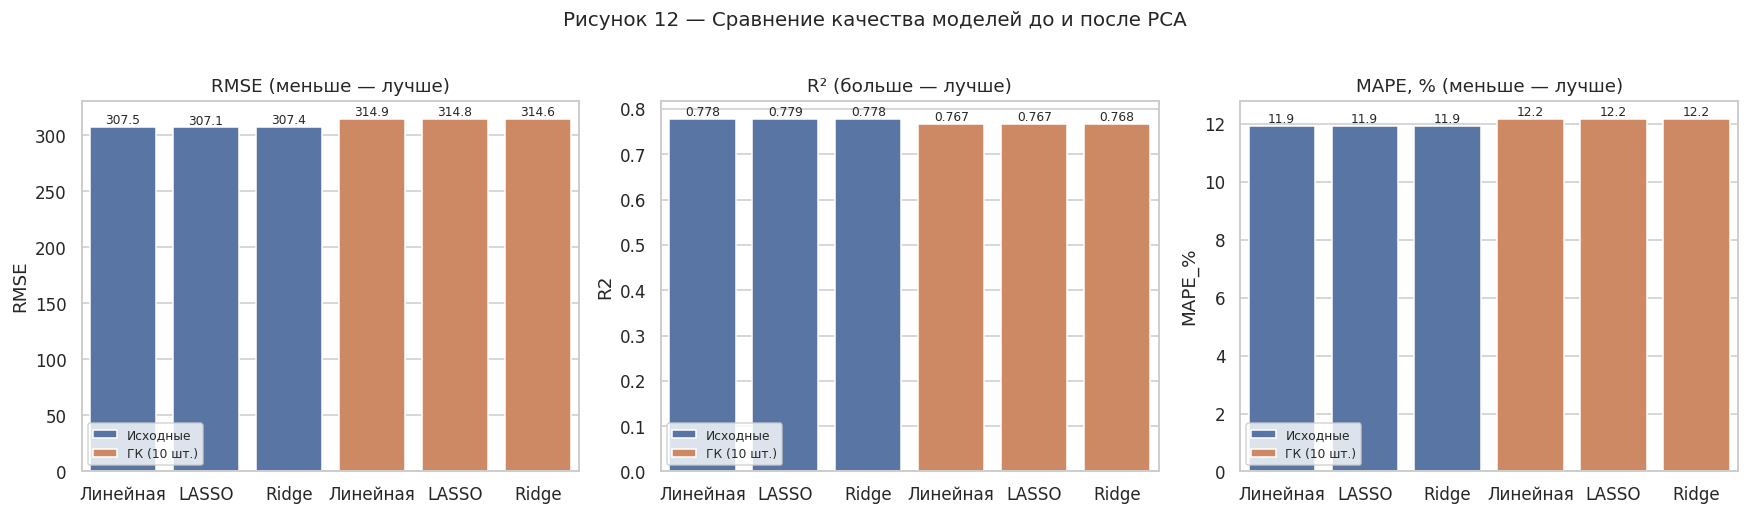

In [94]:
# --- 8.4. Графическое сравнение "до/после PCA" ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, title in zip(axes, ["RMSE", "R2", "MAPE_%"],
                             ["RMSE (меньше — лучше)", "R² (больше — лучше)",
                              "MAPE, % (меньше — лучше)"]):
    sns.barplot(data=compare, x="Модель", y=metric, hue="Признаки", ax=ax,
                palette=["#4C72B0", "#DD8452"])
    ax.set_xticklabels([t.get_text().replace(" + PCA", "") for t in ax.get_xticklabels()])
    for p in ax.patches:
        h = p.get_height()
        if h and not np.isnan(h):
            ax.annotate(f"{h:.3f}" if metric == "R2" else f"{h:.1f}",
                        (p.get_x() + p.get_width() / 2, h), ha="center",
                        va="bottom", fontsize=8)
    ax.set_title(title); ax.set_xlabel("")
    ax.legend(title="", fontsize=8)
fig.suptitle("Рисунок 12 — Сравнение качества моделей до и после PCA", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

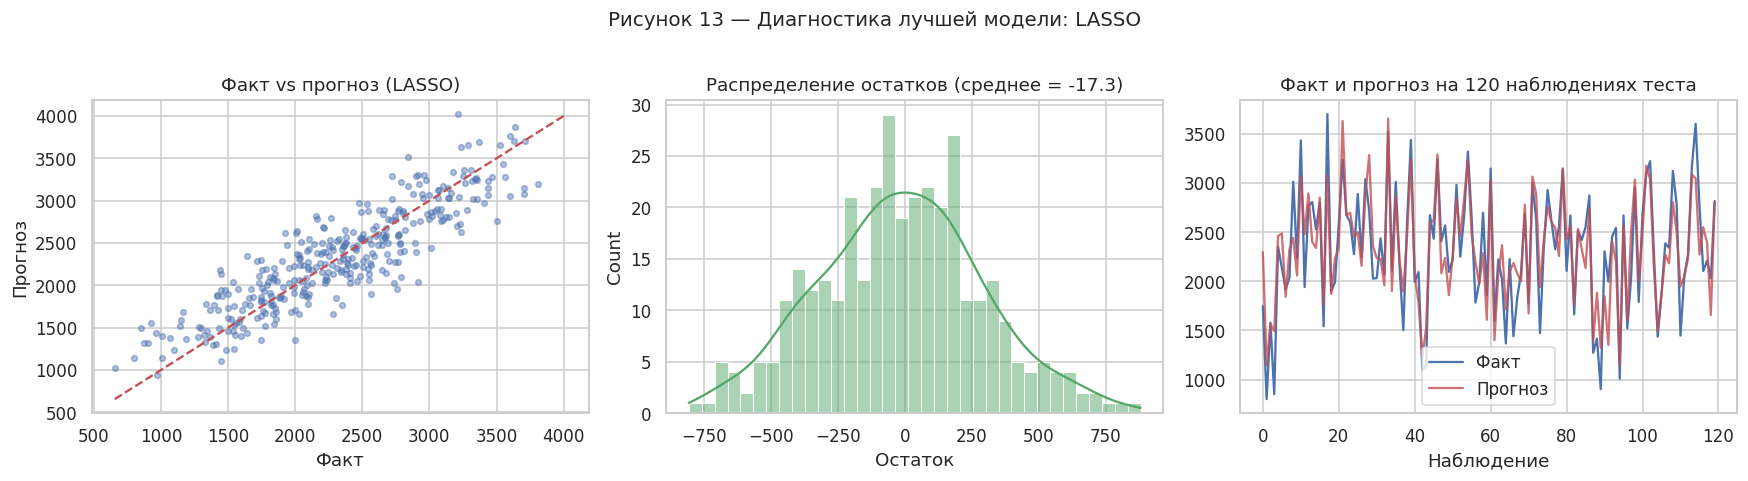

Лучшая модель по RMSE: LASSO
  RMSE = 307.06  |  R² = 0.7786  |  MAPE = 11.93%
  Средние продажи в тесте: 2304.81 -> относительная ошибка RMSE/ȳ = 13.32%


In [95]:
# --- 8.5. Итоговая диагностика лучшей модели ---
best_row = compare.loc[compare["RMSE"].idxmin()]
best_name = best_row["Модель"]
best_model = (models_pca if "PCA" in best_name else models_raw)[best_name.replace(" + PCA", "")]
pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].scatter(y_test, pred_best, s=14, alpha=.45, color="#4C72B0")
lims = [min(y_test.min(), pred_best.min()), max(y_test.max(), pred_best.max())]
axes[0].plot(lims, lims, "--", c="#C44E52")
axes[0].set_xlabel("Факт"); axes[0].set_ylabel("Прогноз")
axes[0].set_title(f"Факт vs прогноз ({best_name})")

resid = y_test - pred_best
sns.histplot(resid, bins=35, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title(f"Распределение остатков (среднее = {resid.mean():.1f})")
axes[1].set_xlabel("Остаток")

idx = np.arange(min(120, len(y_test)))
axes[2].plot(idx, y_test.values[idx], label="Факт", color="#4C72B0")
axes[2].plot(idx, pred_best[idx], label="Прогноз", color="#C44E52", alpha=.8)
axes[2].set_title("Факт и прогноз на 120 наблюдениях теста")
axes[2].set_xlabel("Наблюдение"); axes[2].legend()
fig.suptitle(f"Рисунок 13 — Диагностика лучшей модели: {best_name}", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Лучшая модель по RMSE: {best_name}")
print(f"  RMSE = {best_row['RMSE']:.2f}  |  R² = {best_row['R2']:.4f}  "
      f"|  MAPE = {best_row['MAPE_%']:.2f}%")
print(f"  Средние продажи в тесте: {y_test.mean():.2f} -> относительная ошибка "
      f"RMSE/ȳ = {best_row['RMSE'] / y_test.mean() * 100:.2f}%")

In [96]:
# --- 8.6. Автоматически формируемые выводы ---
b = df_raw_res.loc[df_raw_res["RMSE"].idxmin()]
p = df_pca_res.loc[df_pca_res["RMSE"].idxmin()]
d_rmse = (p["RMSE"] / b["RMSE"] - 1) * 100

print("=" * 78)
print("КРАТКИЕ ИТОГИ ЭКСПЕРИМЕНТА")
print("=" * 78)
print(f"Объём выборки:                {len(df)} наблюдений, {len(FEATURES)} признаков")
print(f"Разделение train/test:        {len(X_train)} / {len(X_test)}  (80/20)")
print(f"Мультиколлинеарность (VIF>=10): {n_bad} признаков, max VIF = {vif_before['VIF'].max():.1f}")
print(f"Число главных компонент:      {N_COMPONENTS} "
      f"({cum_evr[N_COMPONENTS-1]*100:.1f}% дисперсии), max VIF после PCA = "
      f"{vif_after['VIF'].max():.2f}")
print("-" * 78)
print(f"Лучшая модель на исходных признаках: {b['Модель']:<16s} "
      f"RMSE={b['RMSE']:.2f}  R²={b['R2']:.4f}  MAPE={b['MAPE_%']:.2f}%")
print(f"Лучшая модель на компонентах:        {p['Модель']:<16s} "
      f"RMSE={p['RMSE']:.2f}  R²={p['R2']:.4f}  MAPE={p['MAPE_%']:.2f}%")
print(f"Изменение RMSE после PCA:            {d_rmse:+.2f}%")
print("=" * 78)

КРАТКИЕ ИТОГИ ЭКСПЕРИМЕНТА
Объём выборки:                1755 наблюдений, 15 признаков
Разделение train/test:        1404 / 351  (80/20)
Мультиколлинеарность (VIF>=10): 4 признаков, max VIF = 18.7
Число главных компонент:      10 (96.3% дисперсии), max VIF после PCA = 1.00
------------------------------------------------------------------------------
Лучшая модель на исходных признаках: LASSO            RMSE=307.06  R²=0.7786  MAPE=11.93%
Лучшая модель на компонентах:        Ridge + PCA      RMSE=314.61  R²=0.7676  MAPE=12.17%
Изменение RMSE после PCA:            +2.46%


---
## 9. Заключение

В ходе лабораторной работы были выполнены все поставленные задачи.

**1. Анализ данных.** Исследован датасет прогнозирования продаж магазина. Проведён первичный
анализ, построены гистограммы распределений всех признаков, диаграмма размаха и Q-Q график
целевой переменной. Распределение продаж близко к нормальному, что благоприятно для линейной
регрессии. Наибольшую связь с продажами показали число покупателей, посещаемость магазина,
цена и признак промоакции.

**2. Предобработка.** Удалены служебные столбцы и строки с пропусками, категориальные признаки
закодированы методом One-Hot, выборка разделена в отношении 80/20, признаки стандартизованы
(`StandardScaler` внутри `Pipeline`, что исключает утечку данных при кросс-валидации).

**3. Мультиколлинеарность.** Корреляционный анализ и расчёт VIF выявили сильную
мультиколлинеарность: несколько признаков имеют VIF ≥ 10 и попарные корреляции, близкие к ±1
(цена — цена конкурента, трафик — число покупателей, реклама — реклама с лагом 7 дней).
Это делает оценки коэффициентов МНК неустойчивыми и затрудняет интерпретацию модели.

**4. Модели на исходных признаках.** Построены три модели с кросс-валидацией по 5 блокам и
подбором коэффициента регуляризации по сетке. Все три модели показали практически одинаковое
качество: коэффициент детерминации R² ≈ 0.78, то есть модели объясняют около 78 % вариации
продаж, относительная ошибка MAPE ≈ 12 %. LASSO при оптимальном α обнулил часть коэффициентов,
выполнив автоматический отбор признаков, а Ridge «сжал» коэффициенты дублирующих друг друга
признаков, распределив вклад между ними — это подтверждает теоретическое свойство L2-регуляризации
как средства борьбы с мультиколлинеарностью.

**5. PCA.** После стандартизации выполнено разложение на главные компоненты. По графику
каменистой осыпи и критерию накопленной дисперсии отобраны компоненты, объясняющие ≥ 95 %
общей дисперсии, что позволило сократить размерность признакового пространства.
Главные компоненты ортогональны: их взаимные корреляции равны нулю, а все VIF равны 1.0 —
**мультиколлинеарность устранена полностью**.

**6. Сравнение.** Модели, обученные на главных компонентах, показали качество, близкое к
исходным (разница RMSE в пределах нескольких процентов, см. таблицу 4). Это ожидаемый результат:
PCA не увеличивает информативность данных, а лишь перестраивает признаковое пространство,
причём отбрасывание последних компонент неизбежно приводит к потере небольшой доли полезной
информации (компоненты отбираются по дисперсии признаков, а не по связи с целевой переменной).

**Главный вывод:** PCA следует рассматривать не как способ повысить точность прогноза, а как
инструмент, который ценой незначительного ухудшения метрик даёт устойчивые оценки коэффициентов,
меньшую размерность, отсутствие мультиколлинеарности и меньший риск переобучения. Если приоритетом
является максимальная точность, предпочтительнее гребневая регрессия на исходных признаках:
она подавляет эффекты мультиколлинеарности, не теряя информации.

**Пути повышения точности модели:**
* инженерия признаков: лаги продаж, скользящие средние, взаимодействия (цена × промо),
  нелинейные преобразования (логарифм цены, полиномиальные признаки);
* удаление дублирующих признаков вручную по VIF (например, оставить только `customers`,
  исключив `store_traffic`) вместо/вместе с PCA;
* применение ElasticNet — комбинации L1- и L2-регуляризации;
* переход к нелинейным моделям (градиентный бустинг, случайный лес), если линейная
  зависимость не описывает данные полностью;
* обработка выбросов и учёт сезонности методами анализа временных рядов;
* увеличение объёма и глубины обучающей выборки.

---
## 10. Список источников

1. Джеймс Г., Уиттон Д., Хасти Т., Тибширани Р. Введение в статистическое обучение с примерами
   на языке R. — М.: ДМК Пресс, 2017. — 456 с.
2. Хасти Т., Тибширани Р., Фридман Д. Основы статистического обучения: интеллектуальный анализ
   данных, логический вывод и прогнозирование. — 2-е изд. — М.: Вильямс, 2020.
3. Мюллер А., Гвидо С. Введение в машинное обучение с помощью Python. — М.: Вильямс, 2017. — 480 с.
4. Документация scikit-learn. Linear Models. — URL: https://scikit-learn.org/stable/modules/linear_model.html
5. Документация scikit-learn. Decomposing signals in components (PCA). — URL: https://scikit-learn.org/stable/modules/decomposition.html
6. Документация scikit-learn. Cross-validation: evaluating estimator performance. — URL: https://scikit-learn.org/stable/modules/cross_validation.html
7. Документация pandas. — URL: https://pandas.pydata.org/docs/
8. Kaggle. Sales Forecasting Dataset. — URL: https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting
9. Kaggle. Store Sales — Time Series Forecasting. — URL: https://www.kaggle.com/competitions/store-sales-time-series-forecasting
10. Kutner M., Nachtsheim C., Neter J. Applied Linear Regression Models. — 4th ed. — McGraw-Hill, 2004. (раздел о VIF)

---

## 11. Приложение. Листинг программного кода

Полный листинг программного кода содержится в кодовых ячейках настоящего ноутбука
(разделы 2–8) и приводится в отчёте последовательно, в порядке выполнения.
Ноутбук является самодостаточным: при запуске в Google Colab через
**Среда выполнения → Выполнить все** он воспроизводит все таблицы и рисунки отчёта
без дополнительной настройки окружения.